# AUDA Batch Benchmark

Compares **Baseline** preprocessing vs **AUDA** preprocessing across 40 real-world datasets,
grouped by shape category.

| Category | Shape rule |
|---|---|
| `small` | < 200 rows |
| `tall` | > 800 rows |
| `wide` | < 200 rows, > 20 cols |
| `wide_tall` | > 800 rows, > 14 cols |

Both pipelines use **the same `RandomForestClassifier`** — only preprocessing differs.

**Run from `auda_datasets/` with the project venv activated.**

In [1]:
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath('..')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

from auto_eda_agent import AUDA, FeatureTransformer
from auto_eda_agent.profiler import DataProfiler

print('Imports OK')
print(f'Repo root: {REPO_ROOT}')

Imports OK
Repo root: c:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent


In [2]:
DATASETS_DIR = 'datasets'
CONFIG_PATH  = os.path.join(DATASETS_DIR, 'config.json')
MAX_ROWS     = 20_000   # datasets with more rows than this are randomly sampled down

with open(CONFIG_PATH) as f:
    full_registry = json.load(f)

# ── TEST MODE ─────────────────────────────────────────────────────────────
# True  → run only N datasets per category (fast, for testing)
# False → run all 40 datasets (for final results)
TEST_MODE        = True
DATASETS_PER_CAT = 2

if TEST_MODE:
    seen, registry = {}, []
    for entry in full_registry:
        cat = entry['file'].split('/')[0]
        if seen.get(cat, 0) < DATASETS_PER_CAT:
            registry.append(entry)
            seen[cat] = seen.get(cat, 0) + 1
    print(f'TEST MODE: {len(registry)} datasets ({DATASETS_PER_CAT} per category)')
else:
    # registry = full_registry          # ← uncomment this line for full run
    registry = full_registry
    print(f'FULL MODE: {len(registry)} datasets')

pd.DataFrame(registry)[['file', 'target']]

TEST MODE: 8 datasets (2 per category)


,file,target
0,tall/titanic.csv,Survived
1,tall/stroke.csv,stroke
2,wide_tall/ibm_hr_attrition.csv,Attrition
3,wide_tall/telco_churn.csv,Churn
4,small/iris.csv,Species
5,small/haberman.csv,survival_status
6,wide/breast_cancer_wide.csv,diagnosis
7,wide/sonar_wide.csv,Class


In [3]:
# ── Target encoder ────────────────────────────────────────────────────────
def safe_encode_target(y):
    le = LabelEncoder()
    return pd.Series(le.fit_transform(y.fillna('__nan__').astype(str)), name=y.name)


# ── Categorical encoder (shared by both pipelines) ────────────────────────
def encode_categoricals(X_train, X_test):
    cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    if not cat_cols:
        return X_train[num_cols].reset_index(drop=True), X_test[num_cols].reset_index(drop=True)
    for col in cat_cols:
        X_train[col] = X_train[col].fillna('Unknown').astype(str)
        X_test[col]  = X_test[col].fillna('Unknown').astype(str)
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    cat_tr = pd.DataFrame(enc.fit_transform(X_train[cat_cols]), columns=cat_cols)
    cat_te = pd.DataFrame(enc.transform(X_test[cat_cols]),      columns=cat_cols)
    X_tr = pd.concat([X_train[num_cols].reset_index(drop=True), cat_tr], axis=1)
    X_te = pd.concat([X_test[num_cols].reset_index(drop=True),  cat_te], axis=1)
    return X_tr, X_te


# ── Baseline: SimpleImputer(mean) + OrdinalEncoder ────────────────────────
def run_baseline(X_train, X_test):
    X_tr, X_te = X_train.copy(), X_test.copy()
    drop_cols = X_tr.columns[X_tr.isnull().mean() >= 0.6].tolist()
    X_tr = X_tr.drop(columns=drop_cols)
    X_te = X_te.drop(columns=drop_cols, errors='ignore')
    num_cols = X_tr.select_dtypes(include='number').columns.tolist()
    cat_cols = X_tr.select_dtypes(exclude='number').columns.tolist()
    if num_cols:
        imp = SimpleImputer(strategy='mean')
        X_tr[num_cols] = imp.fit_transform(X_tr[num_cols])
        X_te[num_cols] = imp.transform(X_te[num_cols])
    if cat_cols:
        imp = SimpleImputer(strategy='most_frequent')
        X_tr[cat_cols] = imp.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = imp.transform(X_te[cat_cols])
    return encode_categoricals(X_tr, X_te)


# ── AUDA: full 4-stage pipeline + FeatureTransformer ─────────────────────
def run_auda(X_train, y_train, X_test):
    df_tr = X_train.copy()
    df_tr['__target__'] = y_train.values

    agent = AUDA(df_tr, verbose=False)
    agent.run_full_pipeline()
    cleaned = agent.cleaned_df_

    X_tr_c = cleaned.drop(columns=['__target__'])
    y_tr_c = cleaned['__target__'].astype(int)

    keep   = [c for c in X_tr_c.columns if c in X_test.columns]
    X_te_c = X_test[keep].copy()

    # Fill remaining nulls in test using training statistics (no leakage)
    for col in X_tr_c.select_dtypes(include='number').columns:
        if col in X_te_c.columns and X_te_c[col].isnull().any():
            X_te_c[col] = X_te_c[col].fillna(X_tr_c[col].median())
    for col in X_tr_c.select_dtypes(exclude='number').columns:
        if col in X_te_c.columns and X_te_c[col].isnull().any():
            mode_val = X_tr_c[col].mode()
            X_te_c[col] = X_te_c[col].fillna(mode_val.iloc[0] if len(mode_val) else 'Unknown')

    profiler = DataProfiler(X_tr_c)
    profiler.detect_column_types()
    ft = FeatureTransformer(
        X_tr_c, profiler=profiler,
        skew_threshold=1.0, iqr_k=5.0, scale=False, drop_high_cardinality=50
    )
    X_tr_t = ft.fit_transform()
    X_te_t = ft.transform(X_te_c)

    X_tr, X_te = encode_categoricals(X_tr_t.copy(), X_te_t.copy())
    return X_tr, y_tr_c, X_te, agent


# ── Train RF and return metrics ───────────────────────────────────────────
def evaluate(X_train, y_train, X_test, y_test):
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    n_cls  = len(np.unique(np.concatenate([y_train.values, y_test.values])))
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred,
                      average='binary' if n_cls == 2 else 'weighted',
                      zero_division=0)
    try:
        if n_cls == 2:
            auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        else:
            auc = roc_auc_score(y_test, model.predict_proba(X_test),
                                multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')
    return {'accuracy': acc, 'f1': f1, 'auc': auc, 'n_train': len(X_train)}


# ── Extract AUDA pipeline stats ───────────────────────────────────────────
def extract_stats(agent):
    s    = {}
    m    = agent.missing_report_ or {}
    smap = m.get('strategy_map', {})
    s['rows_before']     = m.get('rows_before', 0)
    s['rows_after']      = m.get('rows_after', 0)
    s['missing_handled'] = sum(1 for v in smap.values() if v != 'no_action')
    s['cols_dropped']    = sum(1 for v in smap.values() if v == 'drop_column')
    s['rows_dropped']    = s['rows_before'] - s['rows_after']
    a   = agent.anomaly_report_ or {}
    iqr = a.get('iqr', {})
    iso = a.get('isolation_forest', {})
    s['iqr_outliers']  = sum(v.get('n_outliers', 0) for v in iqr.values() if isinstance(v, dict))
    s['iso_anomalies'] = iso.get('n_anomalies', 0) if isinstance(iso, dict) and 'error' not in iso else 0
    fr = agent.feature_report_ or []
    s['n_suggestions'] = sum(len(r.get('suggestions', [])) for r in fr)
    s['n_rec_cols']    = len(fr)
    return s


print('Helper functions ready.')

Helper functions ready.


## Benchmark Loop

Runs all 40 datasets sequentially.
- Datasets with **> 20 000 rows** are randomly sampled to keep runtime manageable.
- Targets with **> 20 unique values** are skipped (regression, not classification).
- Each step is wrapped in `try/except` so one failure never stops the whole run.

> **Expected runtime:** 15–30 minutes depending on machine.

In [4]:
results = []
TOTAL   = len(registry)

for idx, entry in enumerate(registry, 1):
    fname    = entry['file']
    fp       = os.path.join(DATASETS_DIR, fname)
    tgt      = entry['target']
    category = fname.split('/')[0]
    name     = os.path.basename(fname)
    t0       = time.time()
    row      = {'dataset': name, 'file': fname, 'category': category, 'target': tgt}

    print(f'[{idx:02d}/{TOTAL}] {fname:<50}', end='')

    try:
        # ── Load ──────────────────────────────────────────────────────────
        if not os.path.exists(fp):
            row['status'] = 'missing'
            results.append(row)
            print('SKIP - file not found')
            continue

        df = pd.read_csv(fp, low_memory=False)
        row['n_rows'] = df.shape[0]
        row['n_cols'] = df.shape[1]

        if len(df) > MAX_ROWS:
            df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
            row['sampled'] = True
        else:
            row['sampled'] = False
        row['n_rows_used'] = len(df)

        # ── Validate target (case-insensitive fallback) ────────────────────
        col_lower = {c.strip().lower(): c for c in df.columns}
        if tgt not in df.columns:
            if tgt.lower() in col_lower:
                tgt = col_lower[tgt.lower()]
            else:
                row['status'] = 'no_target'
                results.append(row)
                print('SKIP - target not found')
                continue

        X         = df.drop(columns=[tgt])
        y         = df[tgt]
        n_classes = int(y.dropna().nunique())
        row['n_classes'] = n_classes

        if n_classes < 2:
            row['status'] = 'single_class'
            results.append(row)
            print('SKIP - only 1 class')
            continue
        if n_classes > 20:
            row['status'] = 'too_many_classes'
            results.append(row)
            print(f'SKIP - {n_classes} classes (regression?)')
            continue

        y = safe_encode_target(y)

        # ── Train / test split ─────────────────────────────────────────────
        try:
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y)
        except ValueError:
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=0.2, random_state=42)

        # ── Baseline ──────────────────────────────────────────────────────
        try:
            Xb_tr, Xb_te = run_baseline(X_tr.copy(), X_te.copy())
            mb = evaluate(Xb_tr, y_tr, Xb_te, y_te)
            row['base_acc']     = mb['accuracy']
            row['base_f1']      = mb['f1']
            row['base_auc']     = mb['auc']
            row['base_n_train'] = mb['n_train']
        except Exception as e:
            row['base_acc']     = np.nan
            row['base_f1']      = np.nan
            row['base_auc']     = np.nan
            row['base_n_train'] = np.nan
            row['err_baseline'] = str(e)[:120]

        # ── AUDA ──────────────────────────────────────────────────────────
        try:
            Xa_tr, ya_tr, Xa_te, agent = run_auda(X_tr.copy(), y_tr.copy(), X_te.copy())
            ma = evaluate(Xa_tr, ya_tr, Xa_te, y_te)
            row['auda_acc']     = ma['accuracy']
            row['auda_f1']      = ma['f1']
            row['auda_auc']     = ma['auc']
            row['auda_n_train'] = ma['n_train']
            row.update(extract_stats(agent))
        except Exception as e:
            row['auda_acc']     = np.nan
            row['auda_f1']      = np.nan
            row['auda_auc']     = np.nan
            row['auda_n_train'] = np.nan
            row['err_auda']     = str(e)[:120]

        # ── Deltas ────────────────────────────────────────────────────────
        row['delta_acc'] = row.get('auda_acc', np.nan) - row.get('base_acc', np.nan)
        row['delta_f1']  = row.get('auda_f1',  np.nan) - row.get('base_f1',  np.nan)
        row['delta_auc'] = row.get('auda_auc', np.nan) - row.get('base_auc', np.nan)
        row['status']    = 'ok'

        b_auc   = row.get('base_auc', 0) or 0
        a_auc   = row.get('auda_auc', 0) or 0
        d       = row.get('delta_auc', 0) or 0
        elapsed = round(time.time() - t0, 1)
        icon    = 'UP' if d >= 0 else 'DOWN'
        print(f'AUC {b_auc:.4f}->{a_auc:.4f}  d{d:+.4f}  {elapsed}s  [{icon}]')

    except Exception as e:
        row['status'] = 'error'
        row['error']  = str(e)[:200]
        print(f'ERROR: {e}')

    row['elapsed_s'] = round(time.time() - t0, 1)
    results.append(row)

n_ok = sum(1 for r in results if r.get('status') == 'ok')
sep  = '=' * 60
print(f'\n{sep}')
print(f'Completed: {n_ok}/{len(results)} successful')

[01/8] tall/titanic.csv                                  AUC 0.8290->0.7986  d-0.0304  0.5s  [DOWN]
[02/8] tall/stroke.csv                                   AUC 0.7725->0.7825  d+0.0100  0.5s  [UP]
[03/8] wide_tall/ibm_hr_attrition.csv                    AUC 0.8094->0.7779  d-0.0315  0.6s  [DOWN]
[04/8] wide_tall/telco_churn.csv                         AUC 0.8031->0.8219  d+0.0189  0.8s  [UP]
[05/8] small/iris.csv                                    AUC 1.0000->0.9867  d-0.0133  0.3s  [DOWN]
[06/8] small/haberman.csv                                AUC 0.7962->0.7978  d+0.0016  0.3s  [UP]
[07/8] wide/breast_cancer_wide.csv                       AUC 0.9975->0.9937  d-0.0038  0.4s  [DOWN]
[08/8] wide/sonar_wide.csv                               AUC 0.7368->0.8684  d+0.1316  0.7s  [UP]

Completed: 8/8 successful


In [5]:
df_res = pd.DataFrame(results)
df_ok  = df_res[df_res['status'] == 'ok'].copy()

not_ok = df_res[df_res['status'] != 'ok'][['dataset', 'category', 'status']]
if len(not_ok):
    print('Non-successful entries:')
    print(not_ok.to_string(index=False))
else:
    print('All entries ran successfully!')

print(f'\n{len(df_ok)} datasets in results.')

All entries ran successfully!

8 datasets in results.


## Results Table
Colour gradient on `delta_auc`: green = AUDA improved, red = AUDA degraded.

In [6]:
from IPython.display import display

display_cols = [
    'dataset', 'category', 'n_rows_used', 'n_cols', 'n_classes',
    'base_auc', 'auda_auc', 'delta_auc', 'delta_f1', 'elapsed_s'
]

styled = (
    df_ok[display_cols]
    .sort_values(['category', 'dataset'])
    .style
    .format({
        'base_auc':    '{:.4f}',
        'auda_auc':    '{:.4f}',
        'delta_auc':   '{:+.4f}',
        'delta_f1':    '{:+.4f}',
        'elapsed_s':   '{:.0f}s',
        'n_rows_used': '{:,}',
    })
    .background_gradient(subset=['delta_auc'], cmap='RdYlGn', vmin=-0.05, vmax=0.05)
    .set_caption('Benchmark Results — Baseline vs AUDA')
)
display(styled)

,dataset,category,n_rows_used,n_cols,n_classes,base_auc,auda_auc,delta_auc,delta_f1,elapsed_s
5,haberman.csv,small,199,4,2,0.7962,0.7978,+0.0016,+0.0580,0s
4,iris.csv,small,150,6,3,1.0000,0.9867,-0.0133,-0.1003,0s
1,stroke.csv,tall,"5,110",12,2,0.7725,0.7825,+0.0100,+0.0000,0s
0,titanic.csv,tall,891,12,2,0.8290,0.7986,-0.0304,-0.0379,0s
6,breast_cancer_wide.csv,wide,199,33,2,0.9975,0.9937,-0.0038,+0.0000,0s
7,sonar_wide.csv,wide,100,61,2,0.7368,0.8684,+0.1316,+0.0000,1s
2,ibm_hr_attrition.csv,wide_tall,"1,470",35,2,0.8094,0.7779,-0.0315,-0.0367,1s
3,telco_churn.csv,wide_tall,"7,043",21,2,0.8031,0.8219,+0.0189,+0.0526,1s


## Summary by Category

In [7]:
def win_rate(x):
    pct = (x > 0).mean() * 100
    return f'{pct:.0f}%'

agg_map = {
    'n_datasets':       ('dataset',       'count'),
    'mean_base_auc':    ('base_auc',      'mean'),
    'mean_auda_auc':    ('auda_auc',      'mean'),
    'mean_delta_auc':   ('delta_auc',     'mean'),
    'mean_delta_f1':    ('delta_f1',      'mean'),
    'auda_wins':        ('delta_auc',     lambda x: int((x > 0).sum())),
    'win_rate':         ('delta_auc',     win_rate),
    'mean_missing':     ('missing_handled','mean'),
    'mean_outliers':    ('iqr_outliers',  'mean'),
    'mean_suggestions': ('n_suggestions', 'mean'),
}

summary = df_ok.groupby('category').agg(**agg_map).reset_index()
for col in ['mean_base_auc','mean_auda_auc','mean_delta_auc','mean_delta_f1']:
    summary[col] = summary[col].round(4)
for col in ['mean_missing','mean_outliers','mean_suggestions']:
    if col in summary.columns:
        summary[col] = summary[col].round(1)

sep = '=' * 85
print(sep)
print('  SUMMARY BY CATEGORY')
print(sep)
print(summary.to_string(index=False))

overall_win = (df_ok['delta_auc'] > 0).mean() * 100
mean_delta  = df_ok['delta_auc'].mean()
print(f'\nOverall AUDA win rate : {overall_win:.0f}%')
print(f'Overall mean delta AUC: {mean_delta:+.4f}')

  SUMMARY BY CATEGORY
 category  n_datasets  mean_base_auc  mean_auda_auc  mean_delta_auc  mean_delta_f1  auda_wins win_rate  mean_missing  mean_outliers  mean_suggestions
    small           2         0.8981         0.8922         -0.0059        -0.0211          1      50%           0.0           10.5               7.5
     tall           2         0.8007         0.7905         -0.0102        -0.0190          1      50%           2.0          426.0              32.5
     wide           2         0.8672         0.9311          0.0639         0.0000          1      50%           0.5          139.0             204.5
wide_tall           2         0.8062         0.7999         -0.0063         0.0080          1      50%           0.0          288.5              57.0

Overall AUDA win rate : 50%
Overall mean delta AUC: +0.0104


## Visualisations

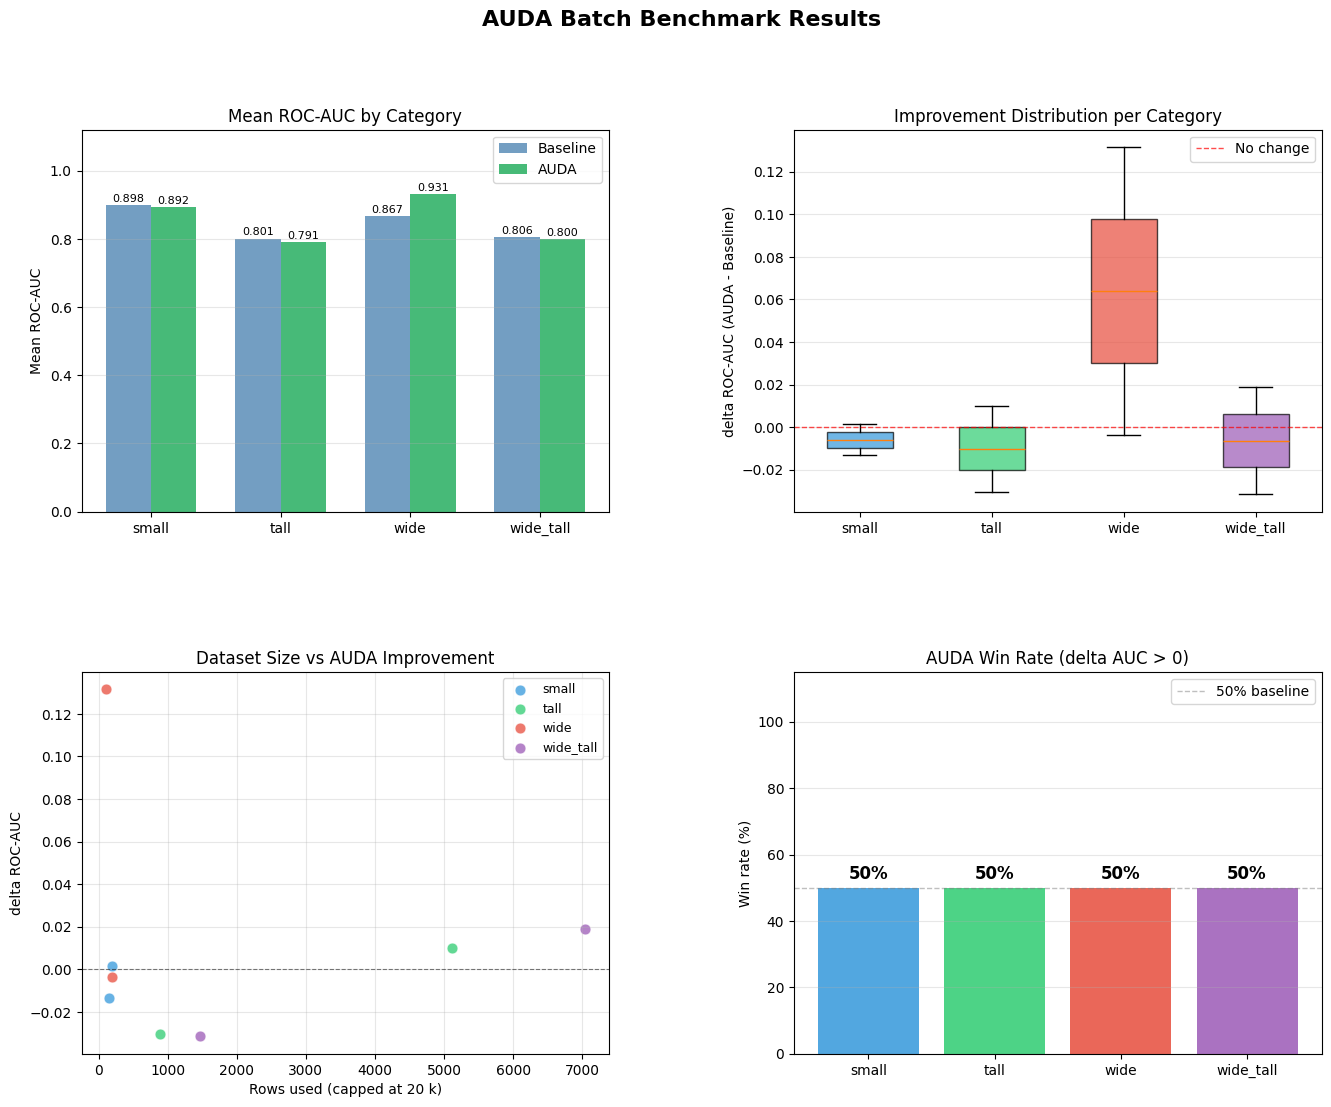

Chart saved to benchmark_results.png


In [8]:
CAT_ORDER  = ['small', 'tall', 'wide', 'wide_tall']
CAT_COLORS = {'small': '#3498DB', 'tall': '#2ECC71', 'wide': '#E74C3C', 'wide_tall': '#9B59B6'}
CATS       = [c for c in CAT_ORDER if c in df_ok['category'].values]

fig = plt.figure(figsize=(16, 12))
fig.suptitle('AUDA Batch Benchmark Results', fontsize=16, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# ── Chart 1: Mean ROC-AUC grouped bar per category ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x, w = np.arange(len(CATS)), 0.35
mean_base = [df_ok[df_ok['category'] == c]['base_auc'].mean() for c in CATS]
mean_auda = [df_ok[df_ok['category'] == c]['auda_auc'].mean() for c in CATS]
b1 = ax1.bar(x - w/2, mean_base, w, label='Baseline', color='#5B8DB8', alpha=0.85)
b2 = ax1.bar(x + w/2, mean_auda, w, label='AUDA',     color='#27AE60', alpha=0.85)
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(CATS, fontsize=10)
ax1.set_ylim(0, 1.12); ax1.set_ylabel('Mean ROC-AUC')
ax1.set_title('Mean ROC-AUC by Category'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# ── Chart 2: Delta ROC-AUC boxplot per category ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
data_by_cat = [df_ok[df_ok['category'] == c]['delta_auc'].dropna().values for c in CATS]
bp = ax2.boxplot(data_by_cat, labels=CATS, patch_artist=True, widths=0.5)
for patch, cat in zip(bp['boxes'], CATS):
    patch.set_facecolor(CAT_COLORS.get(cat, '#999'))
    patch.set_alpha(0.7)
ax2.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='No change')
ax2.set_ylabel('delta ROC-AUC (AUDA - Baseline)')
ax2.set_title('Improvement Distribution per Category')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)

# ── Chart 3: Scatter — dataset size vs delta_auc ──────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for cat in CATS:
    sub = df_ok[df_ok['category'] == cat]
    ax3.scatter(sub['n_rows_used'], sub['delta_auc'],
                label=cat, color=CAT_COLORS.get(cat, '#999'),
                alpha=0.75, s=60, edgecolors='white', linewidths=0.5)
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax3.set_xlabel('Rows used (capped at 20 k)')
ax3.set_ylabel('delta ROC-AUC')
ax3.set_title('Dataset Size vs AUDA Improvement')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── Chart 4: Win rate per category ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
win_rates  = [(df_ok[df_ok['category'] == c]['delta_auc'] > 0).mean() * 100 for c in CATS]
colors4    = [CAT_COLORS.get(c, '#999') for c in CATS]
bars4      = ax4.bar(CATS, win_rates, color=colors4, alpha=0.85)
for bar, v in zip(bars4, win_rates):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{v:.0f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax4.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50% baseline')
ax4.set_ylim(0, 115); ax4.set_ylabel('Win rate (%)')
ax4.set_title('AUDA Win Rate (delta AUC > 0)')
ax4.legend(); ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to benchmark_results.png')

## Top / Bottom Performers & AUDA Pipeline Stats

In [9]:
top_cols = ['dataset', 'category', 'n_rows_used', 'base_auc', 'auda_auc', 'delta_auc']

print('Top 5 datasets where AUDA improved most:')
print(df_ok.nlargest(5, 'delta_auc')[top_cols].to_string(index=False))

print('\nTop 5 datasets where AUDA degraded most:')
print(df_ok.nsmallest(5, 'delta_auc')[top_cols].to_string(index=False))

# AUDA pipeline statistics per category
stat_cols = ['missing_handled', 'cols_dropped', 'rows_dropped',
             'iqr_outliers', 'iso_anomalies', 'n_suggestions']
avail = [c for c in stat_cols if c in df_ok.columns]

sep = '=' * 70
print(f'\n{sep}')
print('  AUDA PIPELINE STATS (mean per dataset, by category)')
print(sep)
if avail:
    pipeline_summary = df_ok.groupby('category')[avail].mean().round(1)
    print(pipeline_summary.to_string())

Top 5 datasets where AUDA improved most:
               dataset  category  n_rows_used  base_auc  auda_auc  delta_auc
        sonar_wide.csv      wide          100  0.736842  0.868421   0.131579
       telco_churn.csv wide_tall         7043  0.803057  0.821942   0.018884
            stroke.csv      tall         5110  0.772510  0.782531   0.010021
          haberman.csv     small          199  0.796238  0.797806   0.001567
breast_cancer_wide.csv      wide          199  0.997494  0.993734  -0.003759

Top 5 datasets where AUDA degraded most:
               dataset  category  n_rows_used  base_auc  auda_auc  delta_auc
  ibm_hr_attrition.csv wide_tall         1470  0.809415  0.777888  -0.031527
           titanic.csv      tall          891  0.828986  0.798551  -0.030435
              iris.csv     small          150  1.000000  0.986667  -0.013333
breast_cancer_wide.csv      wide          199  0.997494  0.993734  -0.003759
          haberman.csv     small          199  0.796238  0.797806   0.

In [10]:
df_res.to_csv('benchmark_results_all.csv', index=False)
df_ok.to_csv('benchmark_results_ok.csv',  index=False)

print(f'Saved benchmark_results_all.csv  ({len(df_res)} rows — all datasets)')
print(f'Saved benchmark_results_ok.csv   ({len(df_ok)} rows — successful only)')

Saved benchmark_results_all.csv  (8 rows — all datasets)
Saved benchmark_results_ok.csv   (8 rows — successful only)
